# Lab 2 &mdash; Fourier transform

## Submission rules:

1. The completed assignment should be prepared as s a Jupyter Notebook (.ipynb file) downloaded from your team's Google Colab. Make sure you made a copy of the notebook above and opened it via UCU email address. Submit the Jupyter Notebook (.ipynb file) to **cms**.
2. There should be only one submission per team. However, don't forget to choose a person from your team who would submit the task, and make sure that the names of all team members are listed in the notebook. Teammates not mentioned in the notebook will not be graded for this lab.
3. This time, you also need to provide a **work breakdown structure** estimating the efforts of each team member. Please provide it at the top of your notebook.
4. This lab requires some visualization from you; please arrange it according to best practices (appropriate axes labels, title, size/scale are a minimum).
5. The final deadline is **March 17 2025, 23:59**. Making any changes to your code after this time and date is forbidden and will be a reason for point deduction for the whole team.

#### Work breakdown:

Nychyporuk Daryna: Sinusoids, Working with example audio \
Moroz Tetiana: Analyzing a song (1, 2, 3, 4) \
Brytan Mykhailo: Analyzing a song (5) \
Syrotiuk Viktor: Analyzing a song (6)

## Introduction
Soon, you will learn about Fourier transform, i.e., an operator that maps functions depending on space (resp. time) variables into functions depending on spatial (resp. temporal) frequency, which is widely used in spectroscopy and signal processing.  

One of the motivations to use Fourier transform comes from the study of Fourier series. In our particular case, you will transform sound (a continuous wave that is a mixture of multiple frequencies) into an arrray of pure frequencies that can be analyzed with the help of Discrete Fourier Transform. The ultimate goal is to decompose a melody into a sequence of pitches and then to notes (without any help of a trained musician's ear &mdash; that would be cheating!).

In [22]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from IPython.display import Audio
from scipy.signal import find_peaks
%matplotlib inline

## Sinusoids

Let's first consider a simple example. Decompose a series sin3 that is a sum of two sinusoids using the Fast Fourier transform from scipy library. FFT is simply a computationally efficient implementation of a discrete Fourier transform. What is the frequency of sin1 and sin2 signals?

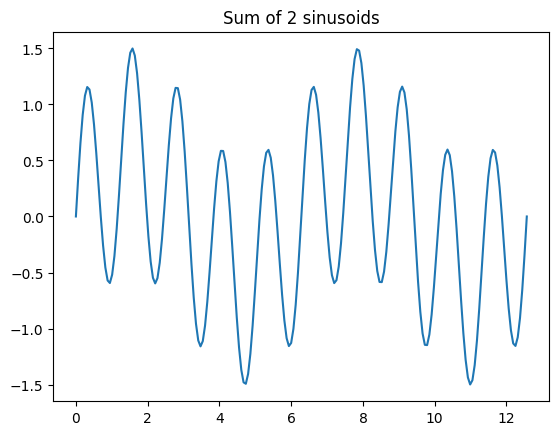

In [23]:
x = np.linspace(0, 4*np.pi, 200)
sin1 = 0.5 * np.sin(x)
sin2 = np.sin(5*x)
sin3 = sin1 + sin2
plt.plot(x, sin3)
plt.title('Sum of 2 sinusoids')
plt.show()

Apply FFT to sin3 series to obtain frequency decomposition and plot the results.

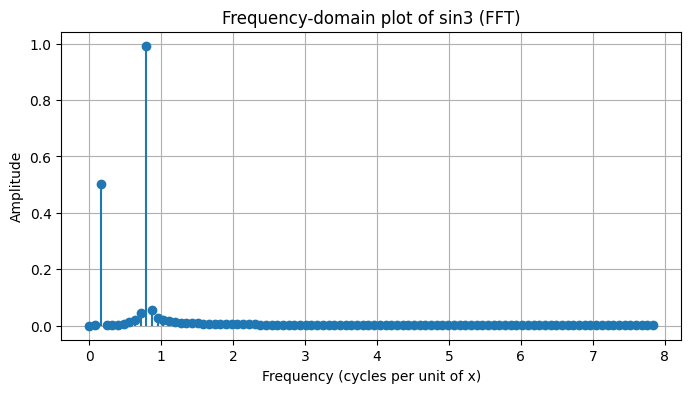

In [24]:
# Apply FFT to sin3 to get frequency decomposition
fft_result = fft(sin3)
frequencies = fftfreq(len(sin3), d=(x[1] - x[0]))

# Keep only non-negative frequencies
positive_mask = frequencies >= 0

# Normalize amplitude
amplitude = 2 / len(sin3) * np.abs(fft_result)

plt.figure(figsize=(8, 4))
plt.stem(frequencies[positive_mask], amplitude[positive_mask], basefmt=" ")
plt.title('Frequency-domain plot of sin3 (FFT)')
plt.xlabel('Frequency (cycles per unit of x)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Make sure that you got 2 spikes corresponding to the frequencies that we assigned to the sinusoids earlier. Explain how the transformation is conducted and why we can obtain two perfectly separated frequencies from a mixed signal.

---

The signal sin3 is made as a sum of two sinusoidal functions:

sin1 = 0.5 sin(x) and sin2 = sin(5x)

So, their angular frequencies are 1 and 5. If we express them as ordinary frequencies in cycles per unit of x, then the expected peaks are at

f1 = 1 / (2π) and f2 = 5 / (2π)

After applying FFT, we can clearly see two spikes in the frequency-domain plot. This means that the transform successfully separates the mixed signal into its two frequency components

The main reason why this works is that the Fourier transform represents the signal using sinusoidal basis functions of different frequencies. These functions are orthogonal, so each frequency component can be identified separately. In a way, this is similar to orthogonal decomposition in linear algebra, where a vector can be split into independent orthogonal parts

We get two clearly separated frequencies here for a few reasons. First, the Fourier transform is linear, so the transform of a sum is equal to the sum of the transforms. Second, the two sinusoidal basis functions are orthogonal. Third, the signal itself contains only two pure sinusoidal components, so the spectrum is simple. Also, with endpoint=False, both sinusoids fit the sampled interval exactly, which helps avoid spreading the energy across nearby frequencies

On the interval [0, 4π), the function sin(x) completes 2 full periods, while sin(5x) completes 10 full periods. Because of this exact fit, the energy stays concentrated at the correct frequency bins, so we get two sharp spikes instead of a blurred spectrum. That is why the two components do not mix with each other in the FFT plot

---

## Working with example audio

Now, let's work with a more complex wave&mdash;sound. Any sound (audio signal) can be characterized by the following three quantities: Pitch, Quality, and Loudness.

Loudness is a physiological sensation that depends mainly on the sound wave pressure (amplitude).

The lowest note in a chord is called fundamental. It is heard predominantly due to larger intensity. Quality is determined by overtones or harmonics that add to the sound of a fundamental note.

Pitch is the frequency of a sound as perceived by human ear. A high frequency gives rise to a high pitch note and a low frequency produces a low pitch note. A pure tone is the sound of only one frequency, such as that given by a tuning fork or electronic signal generator. Naturally, music does not consist of pure tones. Depending on an instrument, technique and many other factors, sound will decay at different rates and one tone will mix with the other ones.

Thus, transcribing audio files into standard music notation (i.e., the notes) is a non-trivial task. We will focus on recognizing pitches and matching them to notes.

### Load and explore

In [25]:
# Load first sound from library examples
# Monophonic trumpet recording
trumpet_path = librosa.example('trumpet')
Audio(trumpet_path)

In [26]:
trumpet_sample, trumpet_sampling_rate = librosa.load(trumpet_path)

What is a sampling rate? What does sampling rate imply about the audio? Is it sufficient for our task (according to https://en.wikipedia.org/wiki/Nyquist%E2%80%93Shannon_sampling_theorem)?


---
*What is a sampling rate?*

The sampling rate (here trumpet_sampling_rate = 22050 Hz) tells us how many times per second the continuous audio signal is measured and converted into a discrete numerical value. In other words, it defines the "resolution" of our digital audio in the time direction

*What does it imply about the audio?*

It means the audio file stores 22,050 amplitude measurements per second of sound. Higher sampling rate → more detail captured → better reconstruction of the original continuous waveform

*Is it sufficient - according to the Nyquist-Shannon theorem?*

The sampling rate is the number of samples taken from a continuous audio signal per second. In this notebook, the audio is loaded with librosa.load, which by default resamples audio to 22050 Hz, so the trumpet recording is represented by 22050 samples per second

According to the Nyquist-Shannon sampling theorem, the sampling rate must be greater than twice the highest frequency we want to capture in order to avoid aliasing. This means that with a sampling rate of 22050 Hz, the highest frequency that can be represented correctly is 11025 Hz, which is the Nyquist frequency

For our task, this is sufficient. We only need the recording for basic pitch-related analysis of a trumpet sound, and the important fundamental frequencies and main harmonics are below this limit. So 22050 Hz is enough for this lab, even though it would not fully cover the entire upper range of human hearing

---

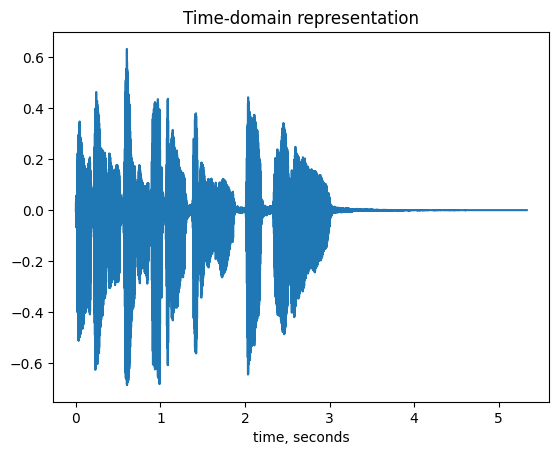

In [27]:
# Initial visualization
time = np.array(range(trumpet_sample.shape[0])) / trumpet_sampling_rate
plt.plot(time, trumpet_sample)
plt.title('Time-domain representation')
plt.xlabel('time, seconds')
plt.show()

This visualization is called the time-domain representation of a given signal. This shows us the loudness (amplitude) of sound wave changing with time. Here amplitude = 0 represents silence. These amplitudes are not very informative as they only represent the loudness of audio recording. To better understand the audio signal, it is necessary to transform it into the frequency domain. The frequency-domain representation of a signal tells us which frequencies are present in the signal.

Decompose the trumpet samples using fft and plot the results. Observe that the frequency pattern corresponds to the pitch changes.

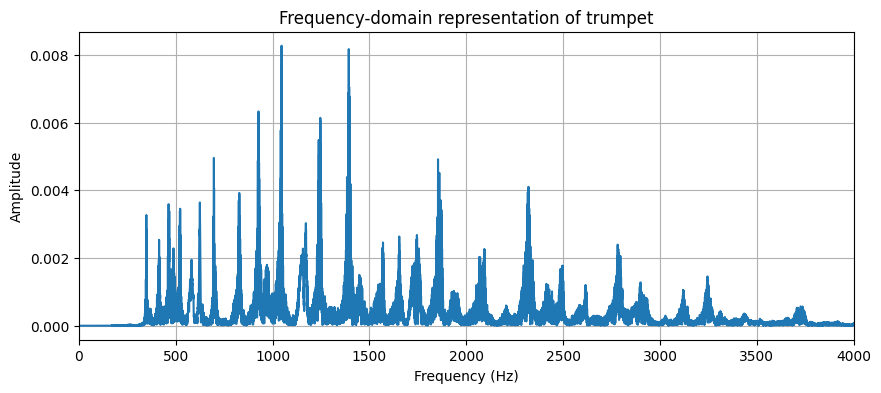

In [28]:
# FFT for trumpet
fft_result = fft(trumpet_sample)
frequencies = fftfreq(len(trumpet_sample), d=1/trumpet_sampling_rate)

# Keep only non-negative frequencies
positive_mask = frequencies >= 0

# Normalize amplitude
amplitude = 2 / len(trumpet_sample) * np.abs(fft_result)

plt.figure(figsize=(10, 4))
plt.plot(frequencies[positive_mask], amplitude[positive_mask])
plt.title('Frequency-domain representation of trumpet')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 4000)
plt.grid(True)
plt.show()

## Analyzing a song

In the next task, you need to use the recording of a famous Ukrainian song (piano_melody.mp3) attached on cms. Your creativity is not limited here so any better ways to compelling visuals, more advanced algorithms on top of FFT or spectrogram, and explanations will be rewarded.     

1.   Load the recording, replay it, and plot in the time domain. To get a better view of how the notes change throughout a shorter time, choose a sample of the audio up to 5 seconds and plot it in the time domain. From here on out you will be working with this smaller 5-second sample.

In [29]:
# Loading sound
path = "piano_melody.mp3"
samples, sampling_rate = librosa.load(path)
Audio(path)
#Creating a 5-second sample of the audio
start_time = 5
samples = samples[int(start_time * sampling_rate):int((start_time + 5) * sampling_rate)]

I selected a 5-second segment from the part where the melody is clearly audible, 

because this makes the time-domain plot and spectrogram more informative.

2.   Build a spectrogram of the sample. Explain what domain the spectrogram represents us and how can it be useful.

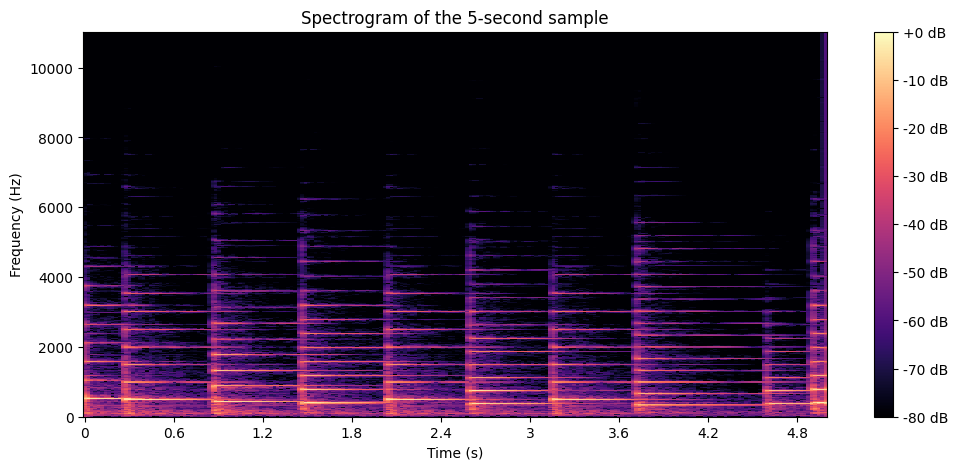

In [30]:
# Compute spectrogram using STFT
D = librosa.stft(samples)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Plot spectrogram
plt.figure(figsize=(12, 5))
librosa.display.specshow(S_db, sr=sampling_rate, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of the 5-second sample')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

---
>**Your explanations here**

---

3.   Transform signal to the frequency domain with FFT and study the distribution of pitches (frequencies).
Observe that the melody contains only a couple of distinct sounds, but there are a lot more spikes in the frequency domain.

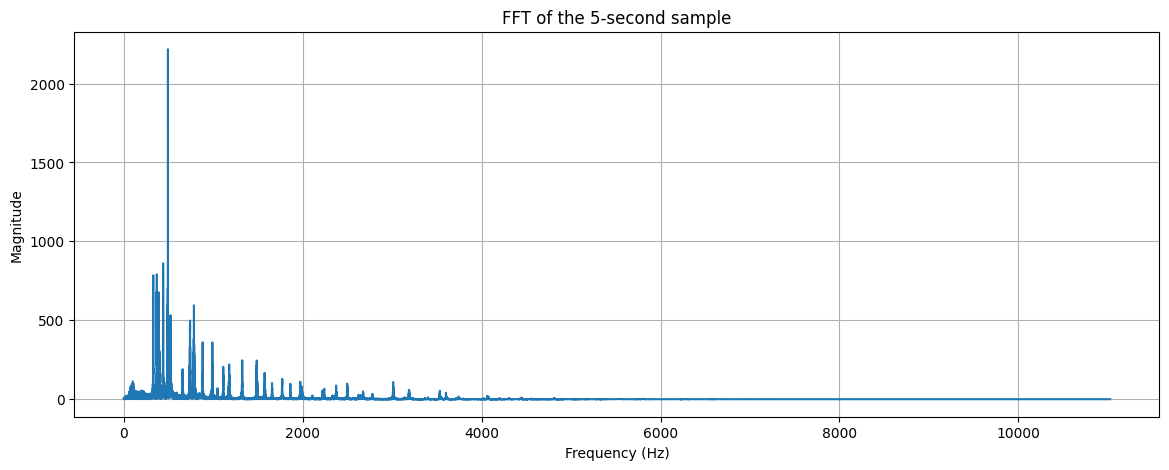

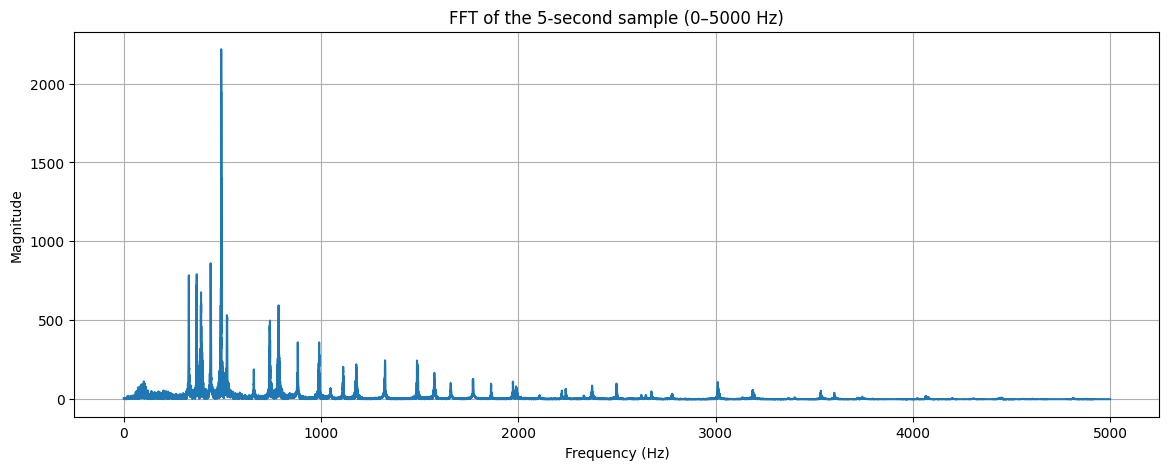

Dominant frequency peaks:
Frequency: 494.20 Hz, Magnitude: 2217.22
Frequency: 440.40 Hz, Magnitude: 861.08
Frequency: 370.20 Hz, Magnitude: 791.83
Frequency: 330.20 Hz, Magnitude: 784.71
Frequency: 391.80 Hz, Magnitude: 677.07
Frequency: 785.00 Hz, Magnitude: 594.78
Frequency: 523.00 Hz, Magnitude: 532.21
Frequency: 741.40 Hz, Magnitude: 497.84
Frequency: 882.20 Hz, Magnitude: 360.18
Frequency: 990.60 Hz, Magnitude: 359.84


In [36]:
#FFT of the 5-second sample
N = len(samples)
fft_vals = np.fft.rfft(samples)
fft_freqs = np.fft.rfftfreq(N, d=1 / sampling_rate)
magnitude = np.abs(fft_vals)

#full frequency spectrum
plt.figure(figsize=(14, 5))
plt.plot(fft_freqs, magnitude)
plt.title("FFT of the 5-second sample")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

#the most relevant musical range
max_freq = 5000
mask = fft_freqs <= max_freq

plt.figure(figsize=(14, 5))
plt.plot(fft_freqs[mask], magnitude[mask])
plt.title("FFT of the 5-second sample (0–5000 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

#dominant peaks
peaks, _ = find_peaks(magnitude, height=np.max(magnitude) * 0.1, distance=50)
peak_freqs = fft_freqs[peaks]
peak_magnitudes = magnitude[peaks]

#sorted peaks by strength
sorted_indices = np.argsort(peak_magnitudes)[::-1]

print("Dominant frequency peaks:")
for i in sorted_indices[:10]:
    print(f"Frequency: {peak_freqs[i]:.2f} Hz, Magnitude: {peak_magnitudes[i]:.2f}")

4. Apply averaging to the initial signal. Averaging is a procedure that reduces number of samples by taking mean of each n of our samples. Experiment with n and determine whichever will work best to both reduce the noise and not loose any information. You can propose other ways to efficiently denoise the signal.

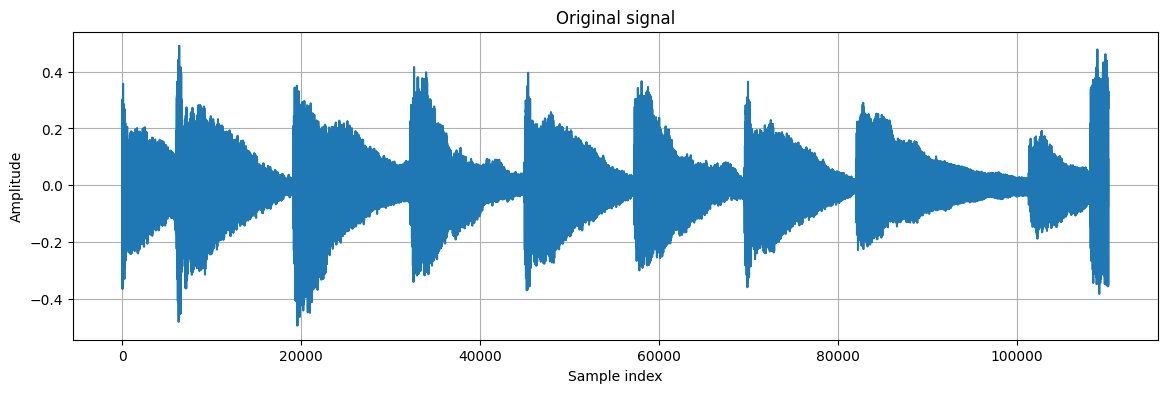

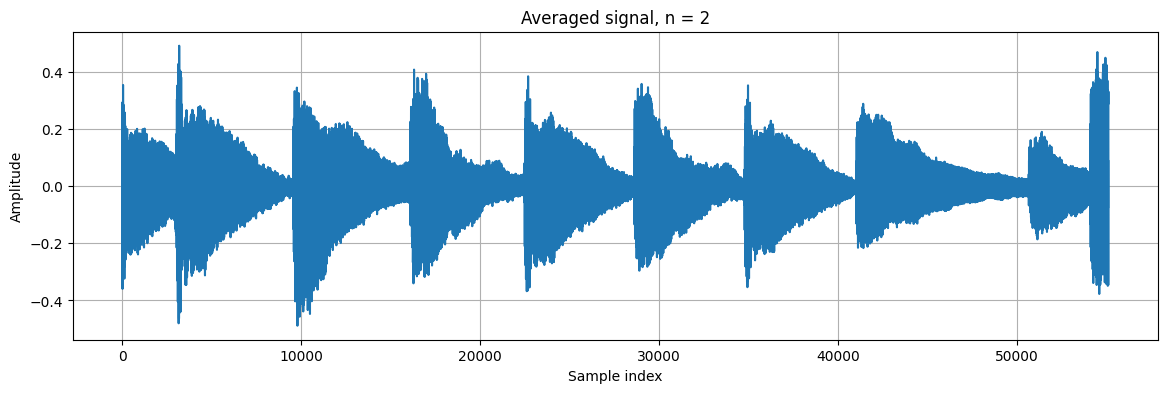

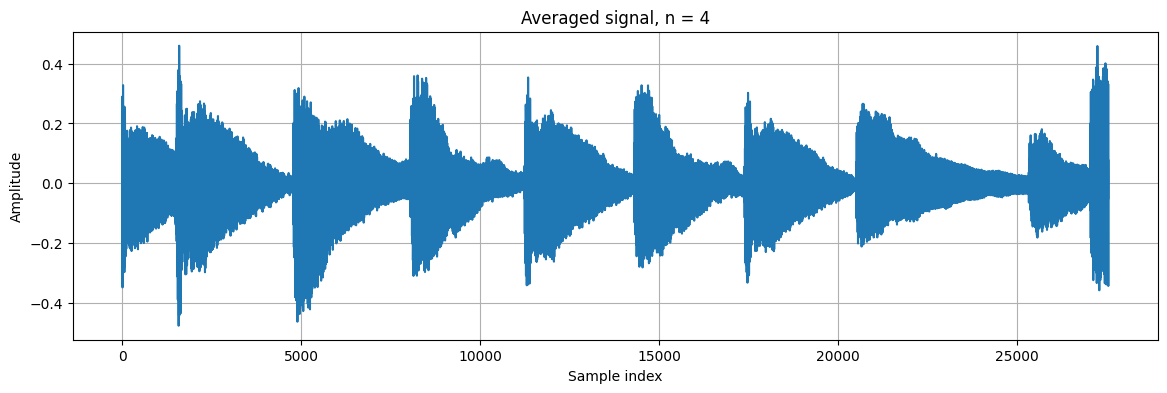

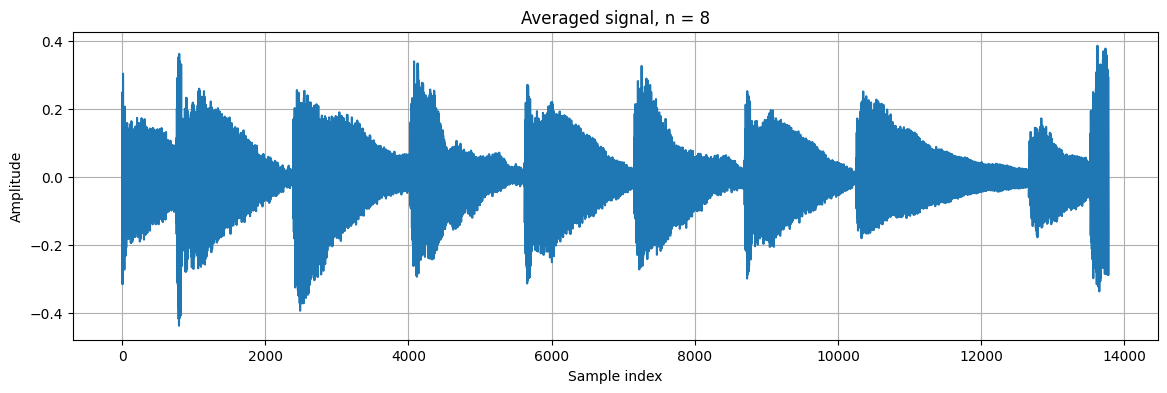

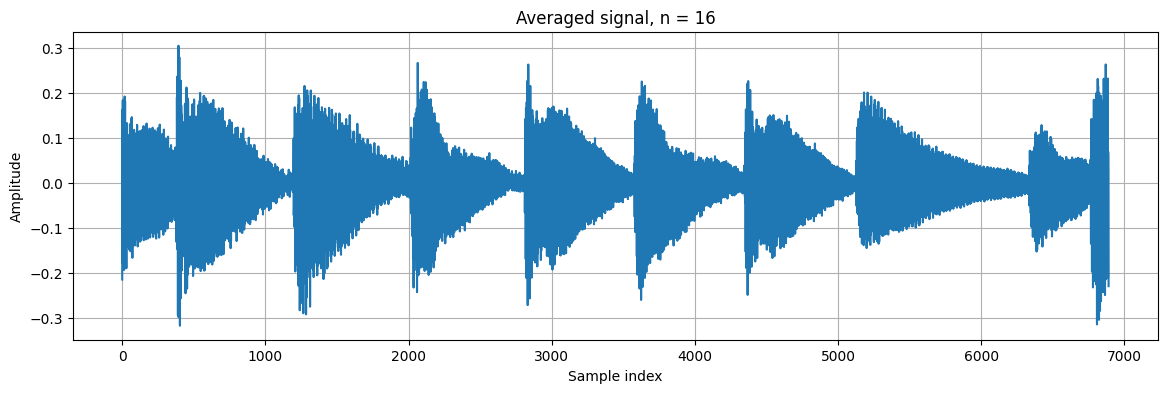

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Function for averaging every n samples
def average_signal(signal, n):
    length = len(signal) // n * n
    signal_cut = signal[:length]
    averaged = signal_cut.reshape(-1, n).mean(axis=1)
    return averaged

# Try different n values
n_values = [2, 4, 8, 16]

# Original signal
plt.figure(figsize=(14, 4))
plt.plot(samples)
plt.title("Original signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# Averaged signals
for n in n_values:
    averaged = average_signal(samples, n)

    plt.figure(figsize=(14, 4))
    plt.plot(averaged)
    plt.title(f"Averaged signal, n = {n}")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

---
Averaging reduces noise by replacing each group of n samples with their mean.

If n is small, the signal changes only a little.

If n is too large, the signal becomes too smooth and some information is lost.

After trying several values, we can choose the one that reduces noise but still keeps the melody visible.

For n = 2 and n = 4, the signal is still quite noisy.

For n = 16, the signal becomes too smooth and some details may be lost.

n = 8 gives the best balance between noise reduction and preserving the melody structure.

---

5. Match fundamental pitches you discovered to the standard note frequencies and display them in a table like the one outlined below.

|Detected frequency(Hz) | Assigned frequency(Hz) | Output note|   
|:---------------------:|:----------------------:|:----------:|
|393.2 |391.9| G4  

|Detected frequency(Hz)|Assigned frequency(Hz)|Output note|
|:--------------------:|:--------------------:|:---------:|
|  330.20|  329.63|   E4    |
|  370.20|  369.99|   F#4   |
|  391.80|  392.00|   G4    |
|  440.40|  440.00|   A4    |
|  494.20|  493.88|   B4    |
|  523.00|  523.25|   C5    |
|  741.40|  739.99|   F#5   |
|  785.00|  783.99|   G5    |


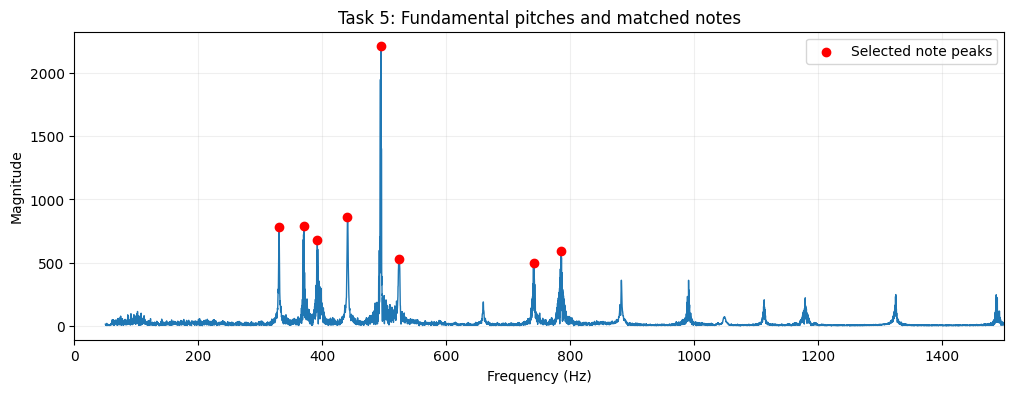

In [33]:
# Task 5: match detected fundamental pitches to standard note frequencies
import os

# Use existing 5-second sample from previous tasks if available.
# If not available, load piano_melody.mp3 and take first 5 seconds.
if 'samples' in globals() and 'sampling_rate' in globals():
    signal = np.asarray(samples, dtype=float)
    sr = sampling_rate
else:
    piano_path = 'piano_melody.mp3'
    if not os.path.exists(piano_path):
        raise FileNotFoundError("Place piano_melody.mp3 near the notebook or set piano_path manually.")
    signal, sr = librosa.load(piano_path, sr=None, mono=True)
    signal = np.asarray(signal, dtype=float)

# Keep only first 5 seconds for analysis consistency
signal = signal[: int(5 * sr)]

# 1) FFT spectrum (one-sided)
N = len(signal)
freqs = np.fft.rfftfreq(N, d=1 / sr)
magnitude = np.abs(np.fft.rfft(signal))

# 2) Focus on musical range to avoid very low/high-frequency noise
fmin, fmax = 50, 2000
mask = (freqs >= fmin) & (freqs <= fmax)
freqs_roi = freqs[mask]
mag_roi = magnitude[mask]

# 3) Detect local maxima above threshold
threshold = np.percentile(mag_roi, 92)
idx = np.where(
    (mag_roi[1:-1] > mag_roi[:-2])
    & (mag_roi[1:-1] > mag_roi[2:])
    & (mag_roi[1:-1] > threshold)
)[0] + 1

peak_freqs = freqs_roi[idx]
peak_mags = mag_roi[idx]

# Sort peaks by amplitude (largest first)
order = np.argsort(peak_mags)[::-1]
peak_freqs = peak_freqs[order]
peak_mags = peak_mags[order]

# 4) Convert strongest spectral peaks to unique notes.
# This naturally suppresses duplicates from neighboring FFT bins.
note_names = np.array(['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'])

def freq_to_midi(freq):
    return int(np.round(69 + 12 * np.log2(freq / 440.0)))

def midi_to_freq(midi):
    return 440.0 * (2 ** ((midi - 69) / 12))

def midi_to_note(midi):
    return note_names[midi % 12] + str((midi // 12) - 1)

best_by_midi = {}
for f, m in zip(peak_freqs, peak_mags):
    midi = freq_to_midi(float(f))

    # Keep only reasonable piano range (A0..C8)
    if midi < 21 or midi > 108:
        continue

    # If this note already exists, keep the stronger peak
    if midi not in best_by_midi or m > best_by_midi[midi][1]:
        best_by_midi[midi] = (float(f), float(m))

# Take strongest unique notes for output table
items = sorted(best_by_midi.items(), key=lambda kv: kv[1][1], reverse=True)[:8]
rows = []
for midi, (f_detected, _) in items:
    rows.append((f_detected, midi_to_freq(midi), midi_to_note(midi)))

# Sort by detected frequency for readability
rows.sort(key=lambda x: x[0])

# 5) Print the required table
print('|Detected frequency(Hz)|Assigned frequency(Hz)|Output note|')
print('|:--------------------:|:--------------------:|:---------:|')
for f_det, f_ass, note in rows:
    print(f'|{f_det:8.2f}|{f_ass:8.2f}|{note:^9s}|')

# Optional visualization of selected note peaks
selected_freqs = np.array([r[0] for r in rows]) if rows else np.array([])

plt.figure(figsize=(12, 4))
plt.plot(freqs_roi, mag_roi, lw=1)
if len(selected_freqs) > 0:
    plt.scatter(
        selected_freqs,
        np.interp(selected_freqs, freqs_roi, mag_roi),
        color='red',
        zorder=3,
        label='Selected note peaks'
    )
plt.xlim(0, 1500)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Task 5: Fundamental pitches and matched notes')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In the last task you will use the recording of Lynyrd Skynyrd - Free Bird.

6.    Experiment with filtering of free_bird.mp3 using Butterworth filter (or other ways which you prefer), so that only bass could be heard. (Hint: you can use [scipy.signal.butter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html)). Replay original and filtered audios. Plot their time and frequency domains.

In [34]:
free_bird_path = # your path
free_bird_samples, free_bird_sampling_rate = librosa.load(free_bird_path)
# Your code here

SyntaxError: invalid syntax (730183931.py, line 1)

---
>**Your explanations here**

---

## Summary

1. What is Fourier transform? How can it be used in signal processing?

2. What are time and frequency domains and how can they be useful?

3. What is averaging and what is its purpose?